## Prophet model on macroscopic data 

In this notebook, the Prophet model is trained on the macroscopic data with 3 different ways :

- First we will try to predict the value of A at time t from the value of A at time t-1 : ***A(t)= Prophet(A(t-1))***
- Secondly we will try to predict the difference between the value of A at time t and the value of A at time t-1 from the difference of the value A at time t-1 and its value at time t-2 : ***A(t+1) = A(t) + Prophet(A(t) - A(t-1))***
- Third, we will do the same thing as we did in the second step just by adding the previous lags of A(t) - A(t-1) : ***A(t+1) = A(t) + Prophet(A(t) - A(t-1),A(t-4) - A(t-5) )***

#### Importing necessary libraries 

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time 
import os
import joblib

from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
base_dir = "predictions"
model_name = "prophet"

model_dir = os.path.join(base_dir, model_name)
os.makedirs(model_dir, exist_ok=True)

#### Loading the data 

In [3]:
data_1 = pd.read_csv("./Macro_lag_1.csv")
data_1 = data_1.dropna()
data_1.head()

,t,A_sample_noisy,A_sample_lag1
1,62.0,0.976038,0.989995
2,122.0,0.976572,0.976038
3,182.0,0.968470,0.976572
4,242.0,0.954645,0.968470
5,302.0,0.951726,0.954645


In [4]:
data_2 = pd.read_csv("./Macro_lag_1_delta_y.csv")

data_2.head()

,t,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1
0,122.0,0.976572,0.976038,0.000534,-0.013957
1,182.0,0.968470,0.976572,-0.008102,0.000534
2,242.0,0.954645,0.968470,-0.013825,-0.008102
3,302.0,0.951726,0.954645,-0.002918,-0.013825
4,362.0,0.942669,0.951726,-0.009057,-0.002918


In [5]:
data_3 = pd.read_csv("./Macro_lag_1_delta_y_delta_lags.csv")

data_3.head()

,t,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5
0,422.0,0.938089,0.942669,-0.004581,-0.009057,0.000534
1,482.0,0.929299,0.938089,-0.008790,-0.004581,-0.008102
2,542.0,0.924808,0.929299,-0.004491,-0.008790,-0.013825
3,602.0,0.926087,0.924808,0.001279,-0.004491,-0.002918
4,662.0,0.916821,0.926087,-0.009266,0.001279,-0.009057


### Functions and Definitions 

In [6]:
def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [7]:
def compute_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100

In [8]:
def compute_nrmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return rmse / (np.max(y_true) - np.min(y_true)) 

In [9]:
def save_experiment_results(
    part,
    model_name,
    method,
    mae,
    nrmse,
    rmse,
    smape,
    r2,
    train_time,
    pred_time,
    file_path="../results.csv"
):
    new_data = {
        "part": part,
        "model": model_name,
        "method": method,
        "mae": mae,
        "nrmse": nrmse,
        "rmse": rmse,
        "smape": smape,
        "r2": r2,
        "train_time": train_time,
        "pred_time": pred_time
    }

    new_row = pd.DataFrame([new_data])

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df = pd.concat([df, new_row], ignore_index=True)
    else:
        df = new_row

    df.to_csv(file_path, index=False)

    print("Results saved successfully!")

In [10]:
def save_model(model, model_name, part, method, folder="../saved_models"):
    os.makedirs(folder, exist_ok=True)

    filename = f"{model_name}_{part}_{method}.pkl"
    path = os.path.join(folder, filename)

    joblib.dump(model, path)

    print(f"Model saved at: {path}")

### Data Splitting 

In [11]:
data_1 = data_1.set_index('t')
data_2 = data_2.set_index('t')
data_3 = data_3.set_index('t')

In [12]:
data_1['ds'] = pd.date_range(
    start='2026-01-01',
    periods=len(data_1),
    freq='60S'
)

data_2['ds'] = pd.date_range(
    start='2026-01-01',
    periods=len(data_2),
    freq='60S'
)

data_3['ds'] = pd.date_range(
    start='2026-01-01',
    periods=len(data_3),
    freq='60S'
)

In [13]:
data_1 = data_1.rename(columns={'A_sample_noisy':'y'})
data_2 = data_2.rename(columns={'delta_y':'y'})
data_3 = data_3.rename(columns={'delta_y':'y'})

In [14]:
train_1 = data_1.loc[data_1.index < 7022] # 20 % pour test et 80 % pour train
test_1 = data_1.loc[data_1.index >= 7022]

train_2 = data_2.loc[data_2.index < 7082] # 20 % pour test et 80 % pour train
test_2 = data_2.loc[data_2.index >= 7082]

train_3 = data_3.loc[data_3.index < 7142] # 20 % pour test et 80 % pour train
test_3 = data_3.loc[data_3.index >= 7142]

In [15]:
print("Train size:", train_1.shape)
print("Test size:", test_1.shape)

Train size: (116, 3)
Test size: (30, 3)


In [16]:
print("Train size:", train_2.shape)
print("Test size:", test_2.shape)

Train size: (116, 5)
Test size: (29, 5)


In [17]:
print("Train size:", train_3.shape)
print("Test size:", test_3.shape)

Train size: (112, 6)
Test size: (28, 6)


### Model Training

##### 1- First equation : ***A(t)= Prophet(A(t-1))***

In [18]:
train_1.head()

,y,A_sample_lag1,ds
t,,,
62.0,0.976038,0.989995,2026-01-01 00:00:00
122.0,0.976572,0.976038,2026-01-01 00:01:00
182.0,0.968470,0.976572,2026-01-01 00:02:00
242.0,0.954645,0.968470,2026-01-01 00:03:00
302.0,0.951726,0.954645,2026-01-01 00:04:00


In [19]:
start_time_training = time.perf_counter()

model_1 = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_1.add_regressor('A_sample_lag1')

model_1.fit(train_1[['ds','y','A_sample_lag1']])

end_time_training = time.perf_counter()
elapsed_time_training = end_time_training - start_time_training
print(f"Execution time of the training: {elapsed_time_training:.4f} seconds")

11:03:21 - cmdstanpy - INFO - Chain [1] start processing
11:03:21 - cmdstanpy - INFO - Chain [1] done processing


Execution time of the training: 0.9053 seconds


In [20]:
start_time_preds = time.perf_counter()

fcst_1 = model_1.predict(test_1)

end_time_preds = time.perf_counter()
elapsed_time_preds = end_time_preds - start_time_preds
print(f"Execution time of the training: {elapsed_time_preds:.4f} seconds")

Execution time of the training: 0.0835 seconds


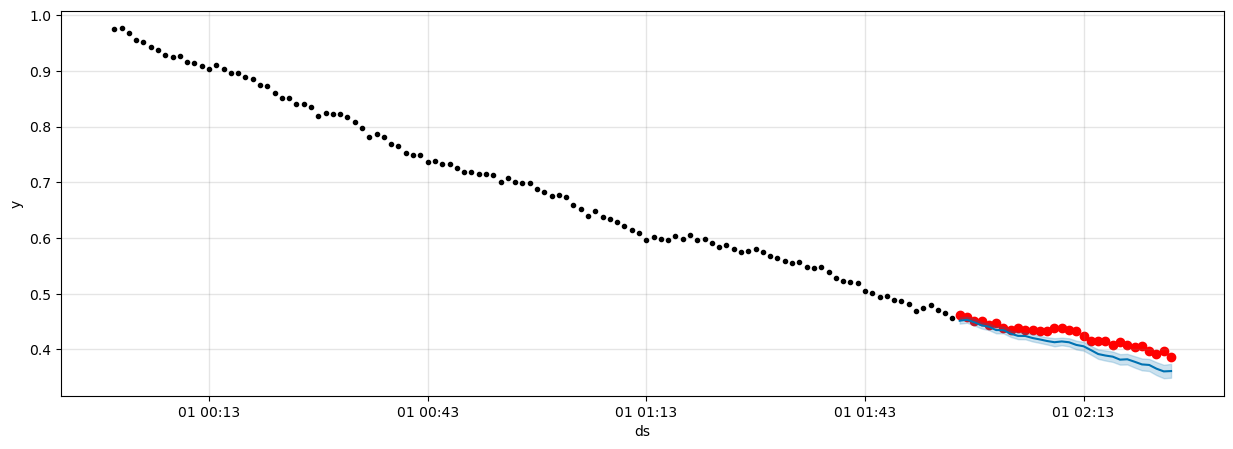

In [21]:
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(test_1['ds'],test_1['y'], color='r')
fig = model_1.plot(fcst_1, ax=ax)

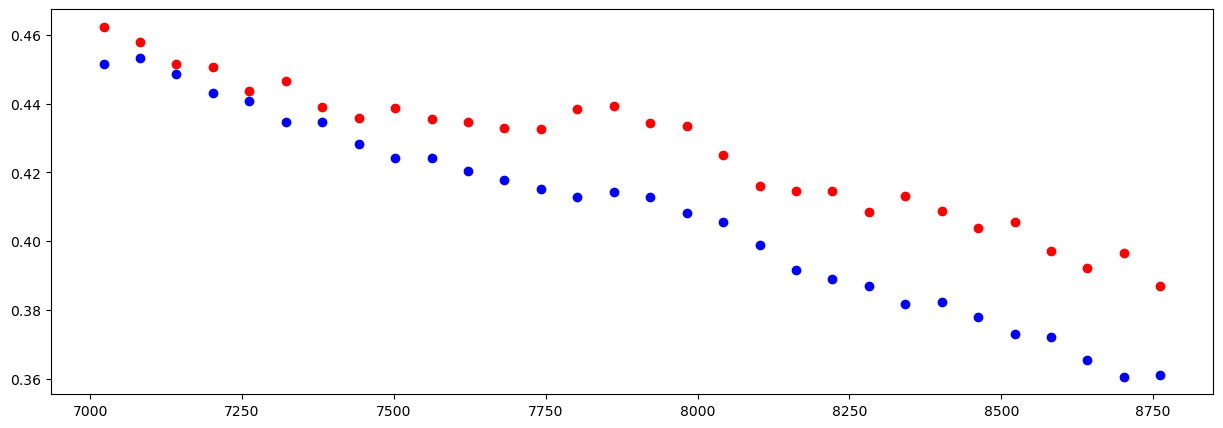

In [22]:
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(test_1.index,test_1['y'], color='r')
ax.scatter(test_1.index,fcst_1['yhat'], color='b')

In [23]:
y_test = test_1['y'].values
y_pred = fcst_1['yhat']
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
smape = compute_smape(y_test, y_pred)
nrmse = compute_nrmse(y_test,y_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print("NRMSE:",nrmse)

RMSE: 0.020758285512905837
MAE: 0.01864780827043718
R2: -0.08646040558824963
sMape: 4.592122136349531
NRMSE: 0.2749413103566604


###### Recursive forcasting

In [24]:
test_1.iloc[0]

y                           0.462388
A_sample_lag1                0.45593
ds               2026-01-01 01:56:00
Name: 7022.0, dtype: object

In [25]:
last_row = train_1.iloc[-1].copy()
future_rows = []
start_time_preds = time.perf_counter()
for i in range(len(test_1)):

    next_ds = last_row['ds'] + pd.Timedelta(minutes=1)

    row_for_pred = pd.DataFrame({
        'ds': [next_ds],
        'A_sample_lag1': [last_row['y']]
    })

    forecast = model_1.predict(row_for_pred)
    #print(forecast['yhat'].values[0])
    predicted_y = forecast['yhat'].values[0]

    new_row = last_row.copy()
    new_row['ds'] = next_ds
    new_row['y'] = predicted_y
    new_row['A_sample_lag1'] = last_row['y']

    future_rows.append(new_row)

    last_row = new_row
    
end_time_preds = time.perf_counter()
elapsed_time_preds = end_time_preds - start_time_preds
print(f"Execution time of the training: {elapsed_time_preds:.4f} seconds")

future_df = pd.DataFrame(future_rows)
full_df = pd.concat([test_1, future_df], ignore_index=True)

Execution time of the training: 1.4992 seconds


In [26]:
future_df.index = test_1.index

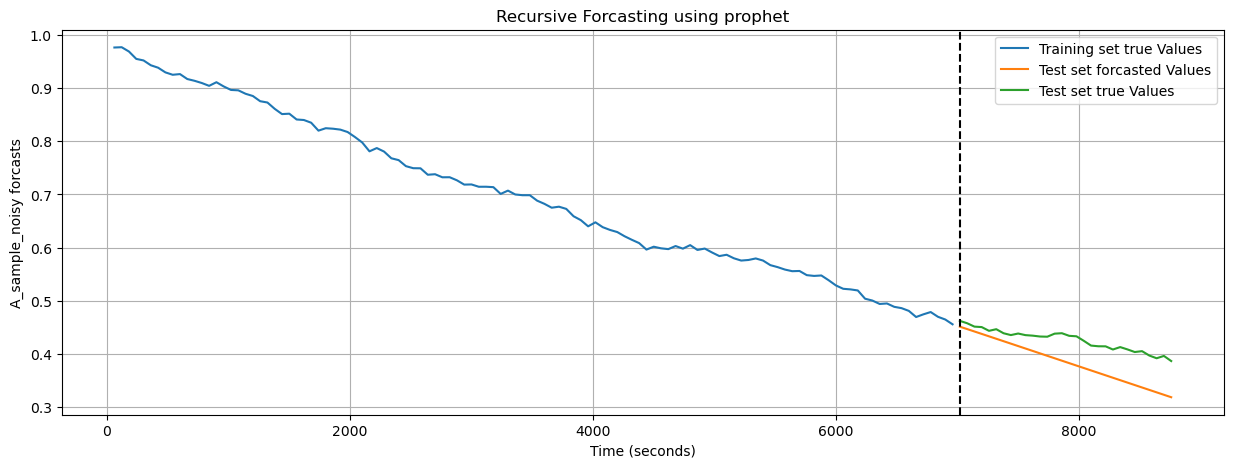

In [27]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train_1.index, train_1['y'], label='Training set true Values')
plt.plot(future_df.index,future_df['y'], label='Test set forcasted Values')
plt.plot(test_1.index, test_1['y'], label='Test set true Values')
ax.axvline(7022, color='black', ls='--')
ax.legend()
plt.grid(True)
plt.xlabel("Time (seconds)")  
plt.ylabel("A_sample_noisy forcasts") 
plt.title('Recursive Forcasting using prophet')
plt.show()

In [28]:
y_test = test_1['y'].values
y_pred = future_df['y']
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
smape = compute_smape(y_test, y_pred)
nrmse = compute_nrmse(y_test,y_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print("NRMSE:",nrmse)

RMSE: 0.04607831596820349
MAE: 0.0410608631481485
R2: -4.353331514322506
sMape: 10.53127711371164
NRMSE: 0.6103024531312874


#### Saving the results of the first model

In [30]:
save_experiment_results(
    part="macro",
    model_name="prophet",
    method="predict_value", 
    mae=mae,
    nrmse=nrmse,
    rmse=rmse,
    smape=smape,
    r2=r2,
    train_time=elapsed_time_training,
    pred_time=elapsed_time_preds
)

Results saved successfully!


In [31]:
save_model(
    model=model_1,
    model_name="prophet",
    part="macro",
    method="predict_value"
)

Model saved at: ../saved_models\prophet_macro_predict_value.pkl


In [32]:
results_df = pd.DataFrame({
    "y_true": test_1['y'].values,
    "y_pred": future_df['y'],
})

results_df.to_csv(os.path.join(model_dir, "predictions_prophet_target_values.csv"), index=False)

##### 2- Second equation : ***A(t+1) = A(t) + Prophet(A(t) - A(t-1))***

In [33]:
train_2.head()

,A_sample_noisy,A_sample_lag1,y,delta_y_lag1,ds
t,,,,,
122.0,0.976572,0.976038,0.000534,-0.013957,2026-01-01 00:00:00
182.0,0.968470,0.976572,-0.008102,0.000534,2026-01-01 00:01:00
242.0,0.954645,0.968470,-0.013825,-0.008102,2026-01-01 00:02:00
302.0,0.951726,0.954645,-0.002918,-0.013825,2026-01-01 00:03:00
362.0,0.942669,0.951726,-0.009057,-0.002918,2026-01-01 00:04:00


In [34]:
start_time_training = time.perf_counter()

model_2 = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_2.add_regressor('delta_y_lag1')

model_2.fit(train_2[['ds','y','delta_y_lag1']])

end_time_training = time.perf_counter()
elapsed_time_training = end_time_training - start_time_training
print(f"Execution time of the training: {elapsed_time_training:.4f} seconds")

11:04:26 - cmdstanpy - INFO - Chain [1] start processing
11:04:26 - cmdstanpy - INFO - Chain [1] done processing


Execution time of the training: 0.2348 seconds


In [35]:
start_time_preds = time.perf_counter()

fcst_2 = model_2.predict(test_2)

end_time_preds = time.perf_counter()
elapsed_time_preds = end_time_preds - start_time_preds
print(f"Execution time of the training: {elapsed_time_preds:.4f} seconds")

Execution time of the training: 0.0871 seconds


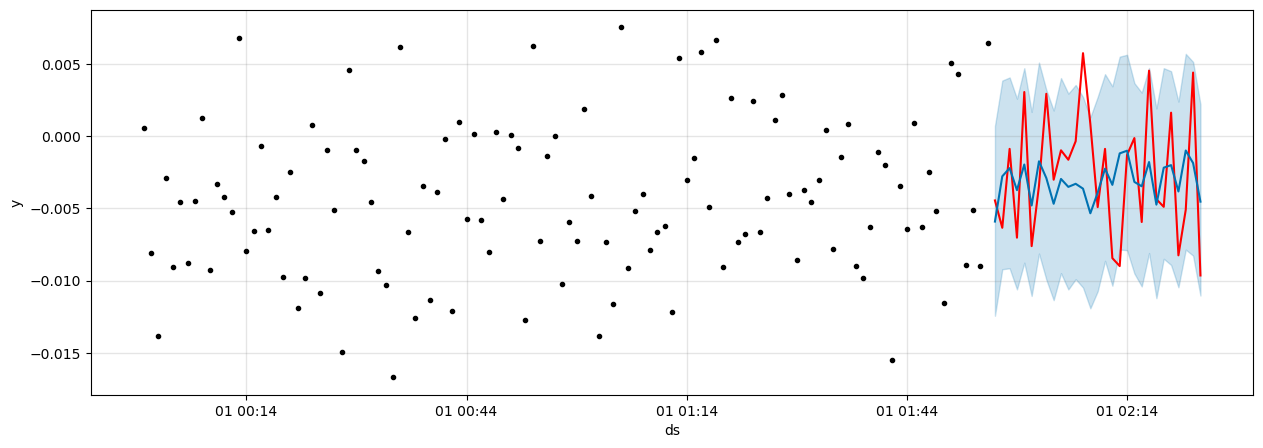

In [36]:
f, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_2['ds'],test_2['y'], color='r')
fig = model_2.plot(fcst_2, ax=ax)

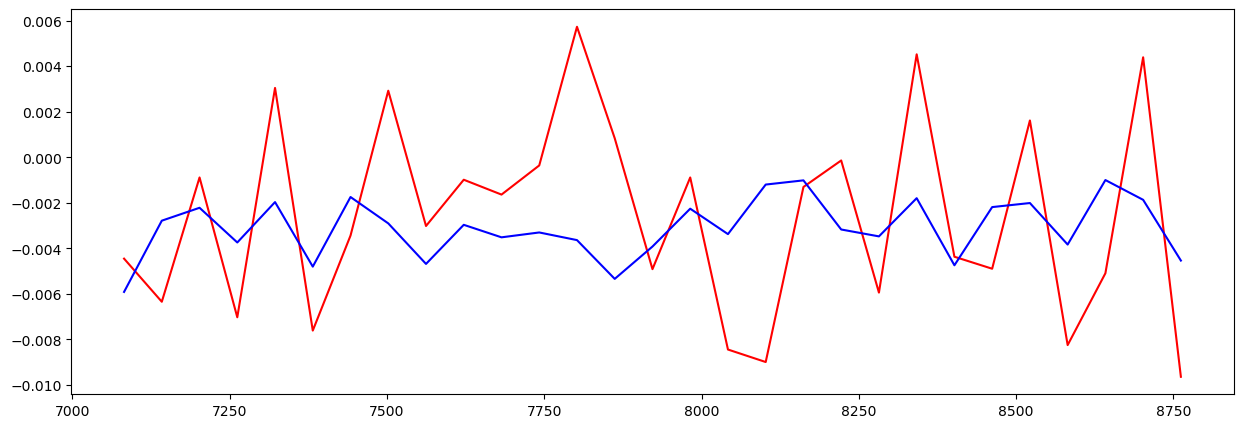

In [37]:
f, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_2.index,test_2['y'], color='r')
ax.plot(test_2.index,fcst_2['yhat'], color='b')

In [38]:
y_test = test_2['y']
y_pred = fcst_2['yhat']
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Mape:",mape)

RMSE: 0.004187751444484959
MAE: 0.0035480802191762174
R2: 0.046941345641880794
Mape: 212.73458389621055


###### Recursive forcasting on the test set

In [41]:
last_row = train_2.iloc[-1]

In [42]:
last_row

A_sample_noisy               0.462388
A_sample_lag1                 0.45593
y                            0.006458
delta_y_lag1                -0.008999
ds                2026-01-01 01:55:00
Name: 7022.0, dtype: object

In [39]:
last_row = train_2.iloc[-1].copy()
future_rows = []

for i in range(len(test_2)):

    next_ds = last_row['ds'] + pd.Timedelta(minutes=1)

    row_for_pred = pd.DataFrame({
        'ds': [next_ds],
        'delta_y_lag1': [last_row['y']]
    })

    forecast = model_2.predict(row_for_pred)
    predicted_y = forecast['yhat'].values[0]

    new_row = last_row.copy()
    #new_row['t'] = last_row['t'] + 60
    new_row['ds'] = next_ds
    new_row['y'] = predicted_y
    new_row['delta_y_lag1'] = last_row['y']

    future_rows.append(new_row)

    last_row = new_row

future_df_test = pd.DataFrame(future_rows)

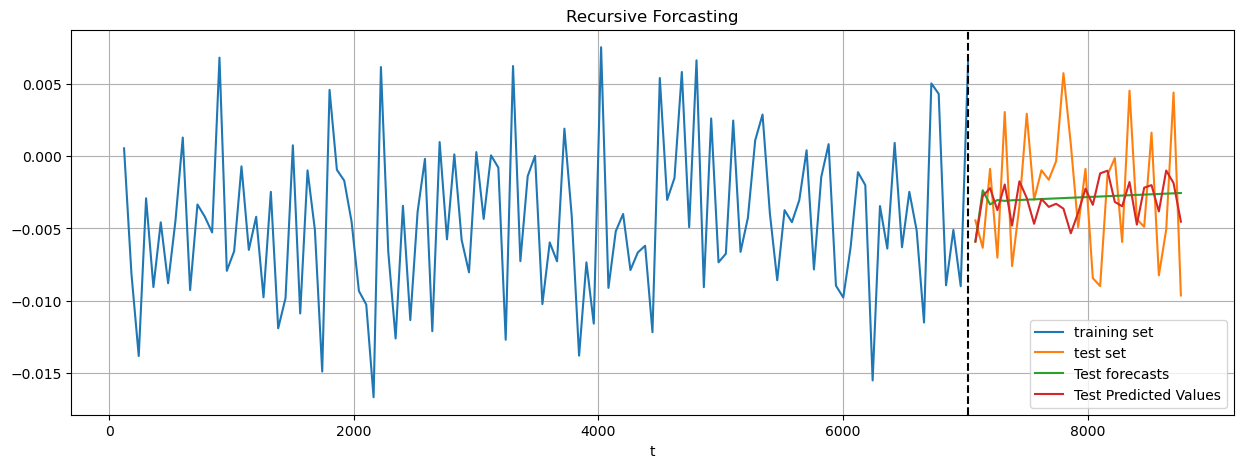

In [51]:
fig, ax = plt.subplots(figsize=(15, 5))
train_2['y'].plot(ax=ax, label='training set ', title='Recursive Forcasting')
test_2['y'].plot(ax=ax, label='test set ', title='Recursive Forcasting')
plt.plot(test_2.index, future_df_test['y'], label='Test forecasts')
plt.plot(test_2.index, fcst_2['yhat'], label='Test Predicted Values')
ax.axvline(7022, color='black', ls='--')
ax.legend()
plt.grid(True)
plt.show()

##### 3- Third equation : ***A(t+1) = A(t) + Prophet(A(t) - A(t-1),A(t-4)-A(t-5) )***

In [52]:
train_3.head()

,A_sample_noisy,A_sample_lag1,y,delta_y_lag1,delta_y_lag5,ds
t,,,,,,
422.0,0.938089,0.942669,-0.004581,-0.009057,0.000534,2026-01-01 00:00:00
482.0,0.929299,0.938089,-0.008790,-0.004581,-0.008102,2026-01-01 00:01:00
542.0,0.924808,0.929299,-0.004491,-0.008790,-0.013825,2026-01-01 00:02:00
602.0,0.926087,0.924808,0.001279,-0.004491,-0.002918,2026-01-01 00:03:00
662.0,0.916821,0.926087,-0.009266,0.001279,-0.009057,2026-01-01 00:04:00


In [53]:
start_time_training = time.perf_counter()

model_3 = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_3.add_regressor('delta_y_lag1')
model_3.add_regressor('delta_y_lag5')

model_3.fit(train_3[['ds','y','delta_y_lag1','delta_y_lag5']])

end_time_training = time.perf_counter()
elapsed_time_training = end_time_training - start_time_training
print(f"Execution time of the training: {elapsed_time_training:.4f} seconds")

12:12:10 - cmdstanpy - INFO - Chain [1] start processing
12:12:11 - cmdstanpy - INFO - Chain [1] done processing


Execution time of the training: 0.6606 seconds


In [54]:
start_time_preds = time.perf_counter()

fcst_3 = model_3.predict(test_3)

end_time_preds = time.perf_counter()
elapsed_time_preds = end_time_preds - start_time_preds
print(f"Execution time of the training: {elapsed_time_preds:.4f} seconds")

Execution time of the training: 0.1072 seconds


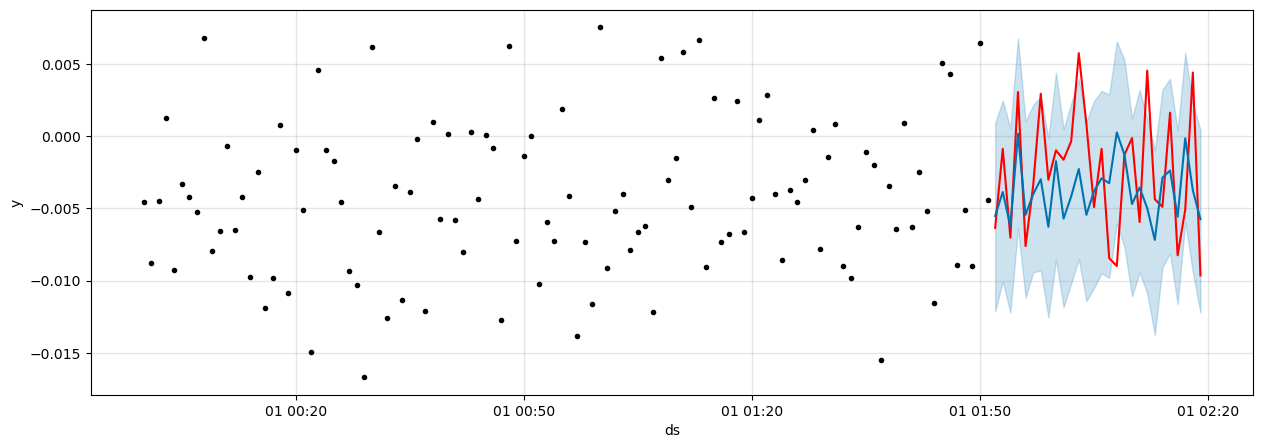

In [55]:
f, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_3['ds'],test_3['y'], color='r')
fig = model_3.plot(fcst_3, ax=ax)

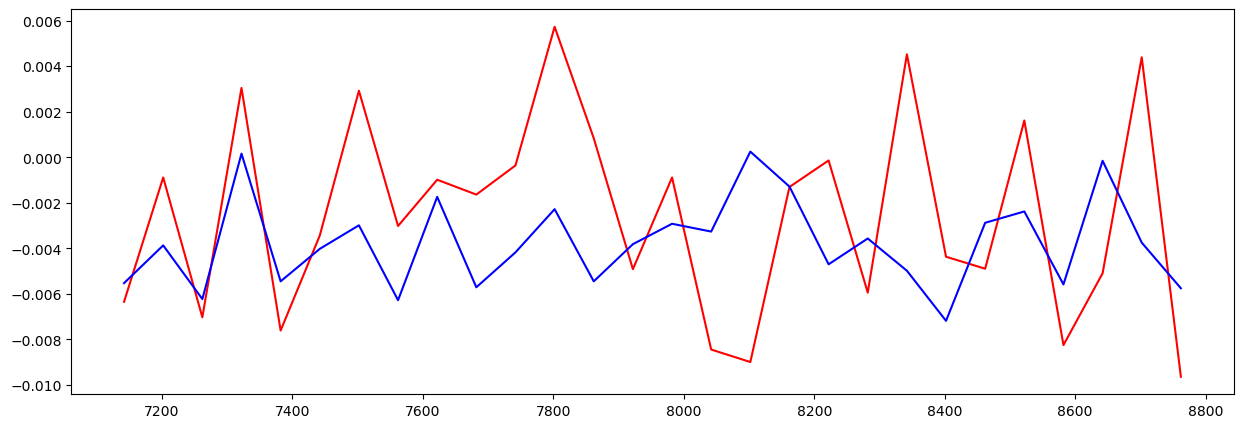

In [56]:
f, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_3.index,test_3['y'], color='r')
ax.plot(test_3.index,fcst_3['yhat'], color='b')

In [57]:
y_test = test_3['y'].values
y_pred = fcst_3['yhat']
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
smape = compute_smape(y_test, y_pred)
nrmse = compute_nrmse(y_test,y_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print('NRMSE',nrmse)

RMSE: 0.004549323189633061
MAE: 0.003742632681685862
R2: -0.09318079895567255
sMape: 107.97729450108524
NRMSE 0.29599276367890787


#### Recursive forecasting on the test set

In [58]:
n_steps = len(test_3)
dy_history = list(train_3['y'].iloc[-5:])

In [59]:
dy_history

[-0.0089366251885067,
 -0.0051075167622275,
 -0.0089986692066116,
 0.0064577290083234,
 -0.0044490242077928]

In [60]:
print(train_3.iloc[-1])

A_sample_noisy               0.457939
A_sample_lag1                0.462388
y                           -0.004449
delta_y_lag1                 0.006458
delta_y_lag5                 0.004303
ds                2026-01-01 01:51:00
Name: 7082.0, dtype: object


In [61]:
history_y = dy_history.copy()

last_ds = train_3.iloc[-1]['ds']
future_rows = []

lags = [1, 5]

start_time_preds = time.perf_counter()

for i in range(n_steps):

    next_ds = last_ds + pd.Timedelta(minutes=1)

    history_y_series = pd.Series(history_y)

    lag_values = {}
    lag_values['delta_y_lag1'] = history_y_series.iloc[-1]
    lag_values['delta_y_lag5'] = history_y_series.iloc[-5] 

    row_for_pred = pd.DataFrame({
        'ds': [next_ds],
        **{k: [v] for k, v in lag_values.items()}
    })

    # Predict
    forecast = model_3.predict(row_for_pred)
    predicted_y = forecast['yhat'].values[0]

    # Store result
    new_row = row_for_pred.copy()
    new_row['y'] = predicted_y
    future_rows.append(new_row)

    # Update history
    history_y.append(predicted_y)
    last_ds = next_ds

# Final dataframe
future_df = pd.concat(future_rows, ignore_index=True)
reconstructed =  future_df["y"].reset_index(drop=True) + test_3["A_sample_lag1"].reset_index(drop=True)

end_time_preds = time.perf_counter()
elapsed_time_preds = end_time_preds - start_time_preds
print(f"Execution time of the training: {elapsed_time_preds:.4f} seconds")

full_df = pd.concat([test_3, future_df], ignore_index=True)

Execution time of the training: 1.7775 seconds


In [62]:
future_df.index = test_3.index

In [63]:
future_df.head()

,ds,delta_y_lag1,delta_y_lag5,y
t,,,,
7142.0,2026-01-01 01:52:00,-0.004449,-0.008937,-0.005524
7202.0,2026-01-01 01:53:00,-0.005524,-0.005108,-0.004025
7262.0,2026-01-01 01:54:00,-0.004025,-0.008999,-0.005618
7322.0,2026-01-01 01:55:00,-0.005618,0.006458,-0.000110
7382.0,2026-01-01 01:56:00,-0.000110,-0.004449,-0.004836


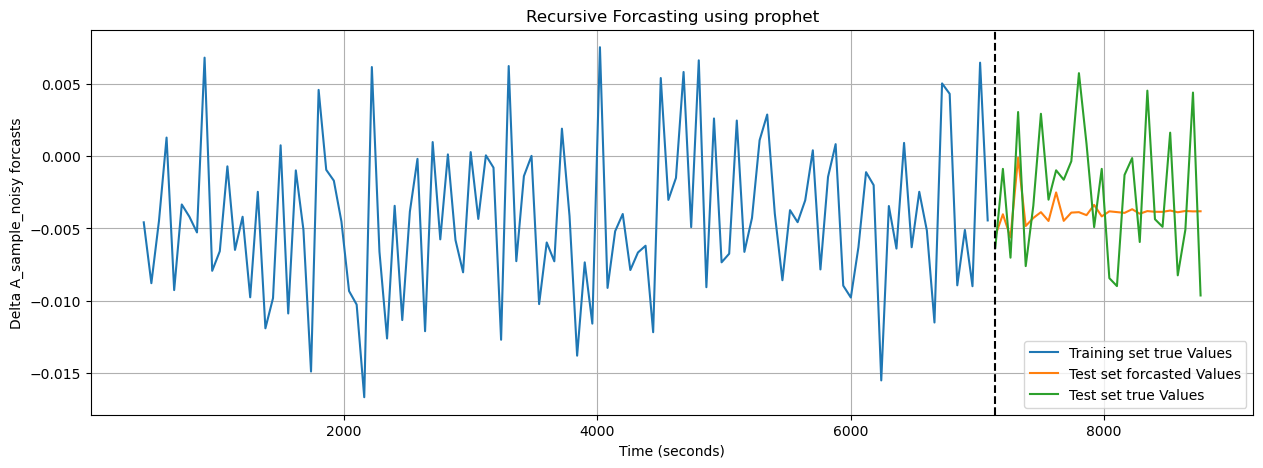

In [64]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train_3.index, train_3['y'], label='Training set true Values')
plt.plot(future_df.index,future_df['y'], label='Test set forcasted Values')
plt.plot(test_3.index, test_3['y'], label='Test set true Values')
ax.axvline(7142, color='black', ls='--')
ax.legend()
plt.grid(True)
plt.xlabel("Time (seconds)")  
plt.ylabel("Delta A_sample_noisy forcasts") 
plt.title('Recursive Forcasting using prophet')
plt.show()

In [65]:
reconstructed

0     0.452414
1     0.447571
2     0.445093
3     0.443577
4     0.441897
5     0.434845
6     0.431811
7     0.434127
8     0.433085
9     0.430136
10    0.429070
11    0.428743
12    0.434270
13    0.435814
14    0.430110
15    0.429575
16    0.421081
17    0.412037
18    0.410989
19    0.410540
20    0.404781
21    0.409256
22    0.404886
23    0.400084
24    0.401585
25    0.393428
26    0.388308
27    0.392708
dtype: float64

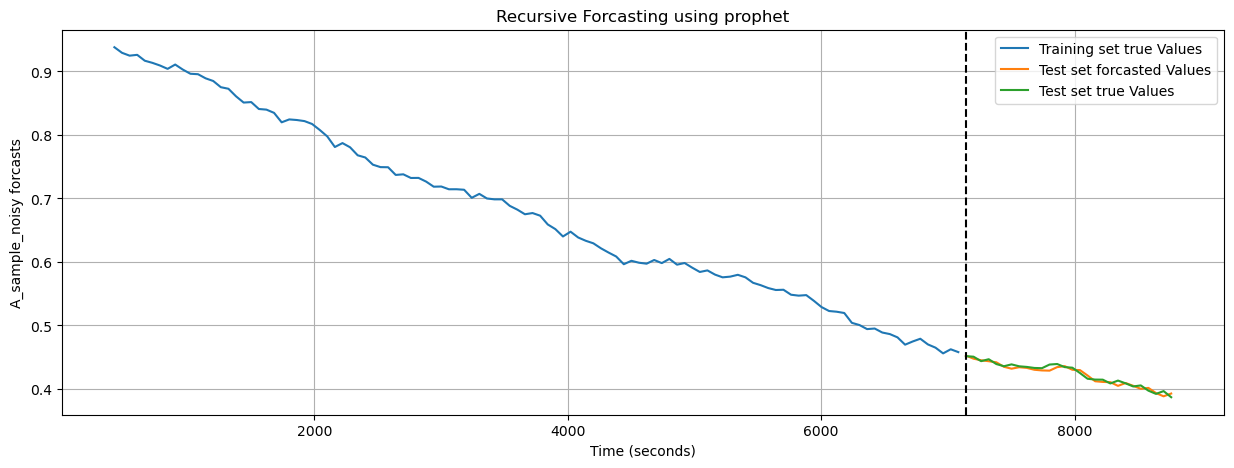

In [66]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train_3.index, train_3['A_sample_noisy'], label='Training set true Values')
plt.plot(test_3.index,reconstructed, label='Test set forcasted Values')
plt.plot(test_3.index, test_3['A_sample_noisy'], label='Test set true Values')
ax.axvline(7142, color='black', ls='--')
ax.legend()
plt.grid(True)
plt.xlabel("Time (seconds)")  
plt.ylabel("A_sample_noisy forcasts") 
plt.title('Recursive Forcasting using prophet')
plt.show()

In [67]:
y_test = test_3['A_sample_noisy'].values
y_pred = reconstructed
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
smape = compute_smape(y_test, y_pred)
nrmse = compute_nrmse(y_test,y_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print('NRMSE',nrmse)

RMSE: 0.00432852595769071
MAE: 0.0035891976126006093
R2: 0.944408352619617
sMape: 0.8557305017251154
NRMSE 0.06689187633283021


#### Saving the results of this third model

In [68]:
save_experiment_results(
    part="macro",
    model_name="prophet",
    method="predict_delta_y", 
    mae=mae,
    nrmse=nrmse,
    rmse=rmse,
    smape=smape,
    r2=r2,
    train_time=elapsed_time_training,
    pred_time=elapsed_time_preds
)

Results saved successfully!


In [69]:
save_model(
    model=model_3,
    model_name="prophet",
    part="macro",
    method="predict_delta_y"
)

Model saved at: ../saved_models\prophet_macro_predict_delta_y.pkl


In [71]:
results_df = pd.DataFrame({
    "y_true": test_3['y'].values,
    "y_pred": future_df["y"],
    "reconstructed" : reconstructed.values 
})

results_df.to_csv(os.path.join(model_dir, "predictions_prophet_target_delta_y.csv"), index=False)